Loading saved dataset and basic inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading the saved data
X = np.load('bragg_signals.npy')
y = np.load('bragg_labels.npy')

depth = np.linspace(0, 30, 300)


print("DATASET OVERVIEW")
print("=" * 40)
print(f"Total signals     : {X.shape[0]}")
print(f"Points per signal : {X.shape[1]}")
print(f"Signal value min  : {X.min():.4f}")
print(f"Signal value max  : {X.max():.4f}")
print(f"Any NaN values?   : {np.isnan(X).any()}")
print(f"Any Inf values?   : {np.isinf(X).any()}")
print(f"Negative values?  : {(X < 0).any()}")
print(f"How many negative : {(X < 0).sum()} out of {X.size} total values")

DATASET OVERVIEW
Total signals     : 6000
Points per signal : 300
Signal value min  : -0.0176
Signal value max  : 1.3045
Any NaN values?   : False
Any Inf values?   : False
Negative values?  : True
How many negative : 43 out of 1800000 total values


Visulaizing the problem

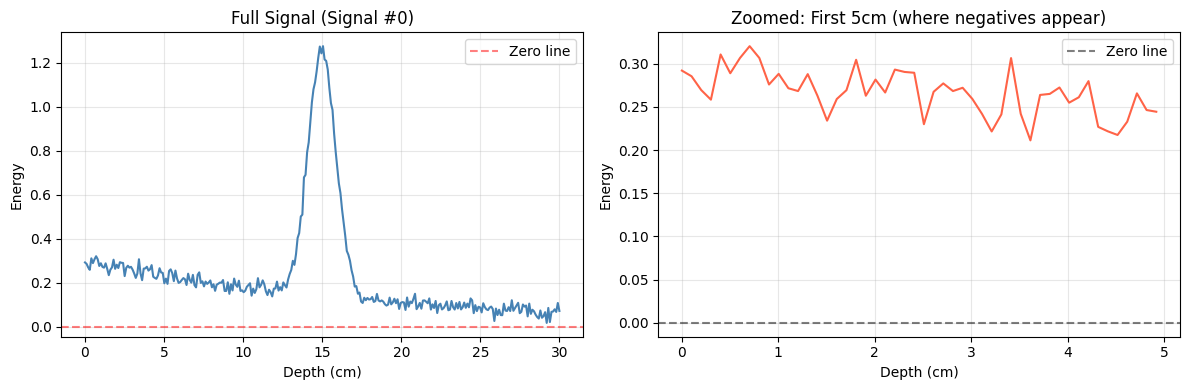


Signals with at least 1 negative value : 43
Max negatives in a single signal       : 1
Average negatives per signal           : 0.01


In [2]:
# Picking one normal signal and zoom into the flat region
sample = X[0]  # first normal signal

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(depth, sample, color='steelblue', linewidth=1.5)
plt.title('Full Signal (Signal #0)')
plt.xlabel('Depth (cm)')
plt.ylabel('Energy')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero line')
plt.legend()

# Zoom into the entrance region (first 5cm) where negatives hide
plt.subplot(1, 2, 2)
plt.plot(depth[:50], sample[:50], color='tomato', linewidth=1.5)
plt.title('Zoomed: First 5cm (where negatives appear)')
plt.xlabel('Depth (cm)')
plt.ylabel('Energy')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Counting negatives per signal
negatives_per_signal = (X < 0).sum(axis=1)
print(f"\nSignals with at least 1 negative value : {(negatives_per_signal > 0).sum()}")
print(f"Max negatives in a single signal       : {negatives_per_signal.max()}")
print(f"Average negatives per signal           : {negatives_per_signal.mean():.2f}")

Clipping negative values

After clipping:
  Min value        : 0.0000  ← should be 0.0
  Any negatives?   : False  ← should be False
  Max value        : 1.3045  ← unchanged


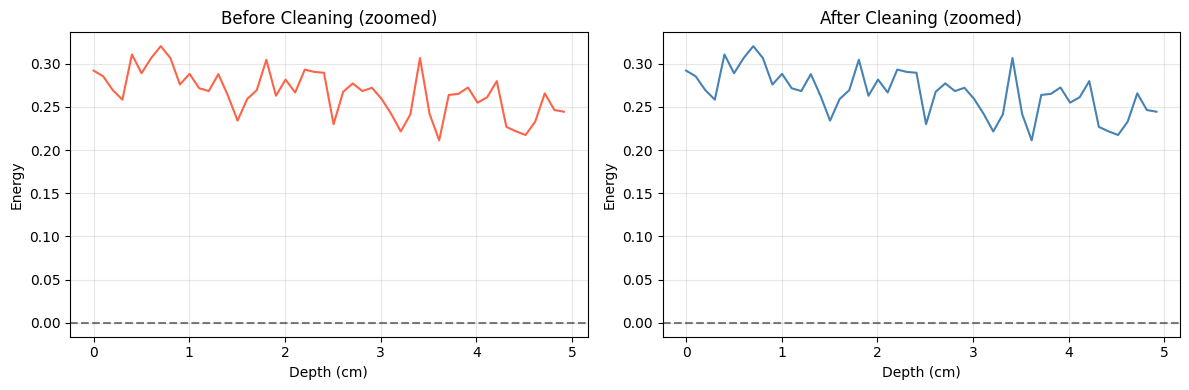

In [3]:
# Clipping: replace any value below 0 with exactly 0
# np.clip(array, min_value, max_value)
# max_value=None means "no upper limit"

X_cleaned = np.clip(X, a_min=0, a_max=None)

# Verifing the fix
print("After clipping:")
print(f"  Min value        : {X_cleaned.min():.4f}  ← should be 0.0")
print(f"  Any negatives?   : {(X_cleaned < 0).any()}  ← should be False")
print(f"  Max value        : {X_cleaned.max():.4f}  ← unchanged")

# Plotting before vs after for same signal
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(depth[:50], X[0][:50], color='tomato', linewidth=1.5)
plt.title('Before Cleaning (zoomed)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Depth (cm)'); plt.ylabel('Energy')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(depth[:50], X_cleaned[0][:50], color='steelblue', linewidth=1.5)
plt.title('After Cleaning (zoomed)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Depth (cm)'); plt.ylabel('Energy')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Normalizing the signals

In [4]:
# For each signal: subtract its min, divide by its range
# Result: every signal goes from 0.0 to 1.0

def normalize_per_signal(X):
    X_min = X.min(axis=1, keepdims=True)   # min of each signal
    X_max = X.max(axis=1, keepdims=True)   # max of each signal
    X_range = X_max - X_min
    
    
    X_range[X_range == 0] = 1
    
    return (X - X_min) / X_range

X_normalized = normalize_per_signal(X_cleaned)

print("After normalization:")
print(f"  Min value : {X_normalized.min():.4f}  ← should be ~0.0")
print(f"  Max value : {X_normalized.max():.4f}  ← should be ~1.0")
print(f"  Shape     : {X_normalized.shape}     ← unchanged")

# Spot check: each signal's own min and max
print(f"Signal 0 → min: {X_normalized[0].min():.2f}, max: {X_normalized[0].max():.2f}")
print(f"Signal 1 → min: {X_normalized[1].min():.2f}, max: {X_normalized[1].max():.2f}")
print(f"Signal 9 → min: {X_normalized[9].min():.2f}, max: {X_normalized[9].max():.2f}")

After normalization:
  Min value : 0.0000  ← should be ~0.0
  Max value : 1.0000  ← should be ~1.0
  Shape     : (6000, 300)     ← unchanged
Signal 0 → min: 0.00, max: 1.00
Signal 1 → min: 0.00, max: 1.00
Signal 9 → min: 0.00, max: 1.00


Visual check for one signal Per class

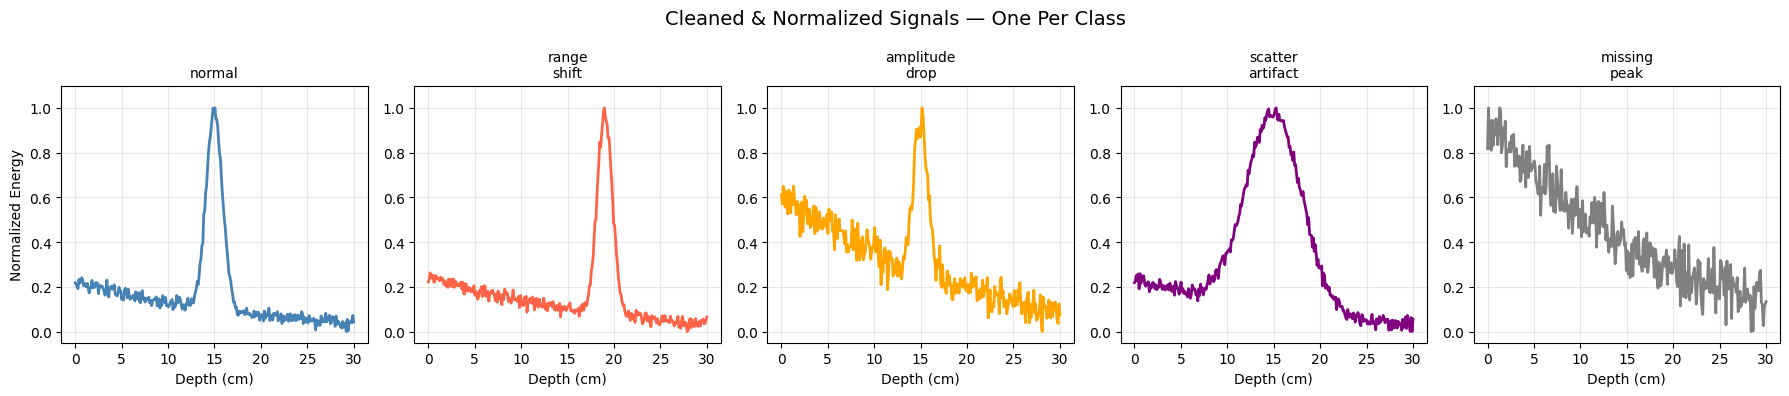

In [5]:
label_list = ['normal', 'range_shift', 'amplitude_drop', 'scatter_artifact', 'missing_peak']
colors = ['steelblue', 'tomato', 'orange', 'purple', 'gray']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Cleaned & Normalized Signals — One Per Class', fontsize=14)

for ax, label, color in zip(axes, label_list, colors):
    # Find first index of this label
    idx = np.where(y == label)[0][0]
    ax.plot(depth, X_normalized[idx], color=color, linewidth=2)
    ax.set_title(label.replace('_', '\n'), fontsize=10)
    ax.set_xlabel('Depth (cm)')
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Normalized Energy')
plt.tight_layout()
plt.show()

Now these graphs show the cleaned and normalized versions of your signals, which means all curves are scaled to a similar range (0 to 1) and noise or inconsistencies have been reduced.

After normalization, the patterns are much clearer and easier to compare. The normal signal has a sharp, well-defined peak at the expected depth, making it the reference pattern. The range shift still shows the peak, but it is clearly shifted to a deeper position, which stands out more after normalization. The amplitude drop case now highlights that although the peak exists, the overall signal shape before and after the peak is different, indicating reduced energy consistency. The scatter artifact appears smoother and wider, showing a broader peak compared to the normal signal, which reflects loss of precision. The missing peak signal remains without a distinct peak and shows a gradual decline, making it very easy to distinguish from the others.

Overall, normalization has made the differences between each class more visible and consistent, which is very important for machine learning models because it helps them focus on the shape and pattern of the signal rather than differences in scale or noise.

Saving cleaned data

In [6]:
np.save('bragg_signals_cleaned.npy', X_normalized)
np.save('bragg_labels.npy', y)  

print("Cleaned data saved!")
print(f"   File: bragg_signals_cleaned.npy")
print(f"   Shape: {X_normalized.shape}")

Cleaned data saved!
   File: bragg_signals_cleaned.npy
   Shape: (6000, 300)


In [7]:
print("PHASE 2 SUMMARY")
print("-" * 35)
print(f"Total signals      : {X_normalized.shape[0]}")
print(f"Points per signal  : {X_normalized.shape[1]}")
print(f"Min value          : {X_normalized.min():.4f}")
print(f"Max value          : {X_normalized.max():.4f}")
print(f"Any negatives?     : {(X_normalized < 0).any()}")
print(f"Any NaN?           : {np.isnan(X_normalized).any()}")
print(f"Any Inf?           : {np.isinf(X_normalized).any()}")

PHASE 2 SUMMARY
-----------------------------------
Total signals      : 6000
Points per signal  : 300
Min value          : 0.0000
Max value          : 1.0000
Any negatives?     : False
Any NaN?           : False
Any Inf?           : False
